In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
data = pd.read_csv("/content/liver_cirrhosis.csv")

In [3]:
label_encoders = {}
categorical_columns = ['Gender', 'Alcohol_Consumption', 'Jaundice', 'Ascites', 'Hepatic_Encephalopathy']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [4]:
data['Diagnosis'] = LabelEncoder().fit_transform(data['Diagnosis'])  # 0: Non-Cirrhosis, 1: Cirrhosis

In [5]:
scaler = StandardScaler()
numerical_columns = ['Age', 'Bilirubin_Level', 'Albumin_Level', 'Prothrombin_Time', 'Platelet_Count']
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [6]:
data['Text_Features'] = data.astype(str).agg(' '.join, axis=1)


In [7]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['Text_Features'])
X = tokenizer.texts_to_sequences(data['Text_Features'])
X = pad_sequences(X, maxlen=100)  # Pad sequences to the same length
y = data['Diagnosis'].values

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Define LSTM model
from tensorflow.keras.regularizers import l2

model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(48, dropout=0.3, recurrent_dropout=0.3, return_sequences=True, kernel_regularizer=l2(0.001)),
    LSTM(24, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(0.001)),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
# Train model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 361ms/step - accuracy: 0.5301 - loss: 0.8963 - val_accuracy: 0.5171 - val_loss: 0.8580
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.6298 - loss: 0.8446 - val_accuracy: 0.7415 - val_loss: 0.8129
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - accuracy: 0.7298 - loss: 0.7995 - val_accuracy: 0.7610 - val_loss: 0.7614
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.7968 - loss: 0.7345 - val_accuracy: 0.7805 - val_loss: 0.6770
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.8311 - loss: 0.6291 - val_accuracy: 0.8098 - val_loss: 0.5606
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.8778 - loss: 0.4773 - val_accuracy: 0.8683 - val_loss: 0.4308
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 267ms/step - accuracy: 0.9418 - loss: 0.3295 - val_accuracy: 0.9610 - val_loss: 0.2931
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.9890 - loss: 0.1839 - val_accuracy: 0

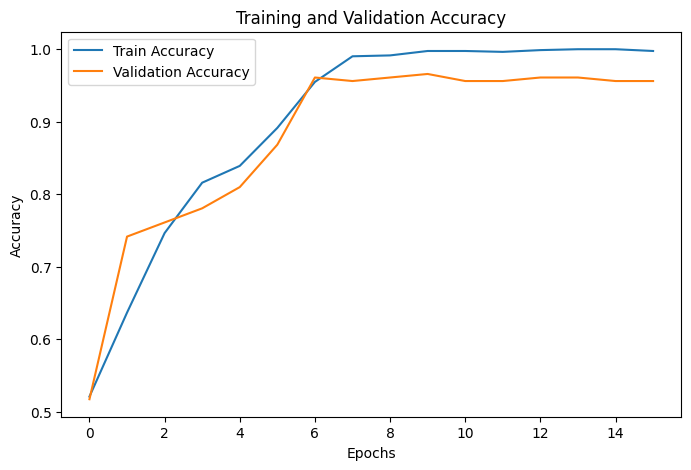

In [11]:
# Plot accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [12]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9667 - loss: 0.1440
Test Accuracy: 96.10%


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [14]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.9610
Precision: 0.9712
Recall: 0.9528
F1 Score: 0.9619
ROC AUC: 0.9613
Confusion Matrix:
[[ 96   3]
 [  5 101]]


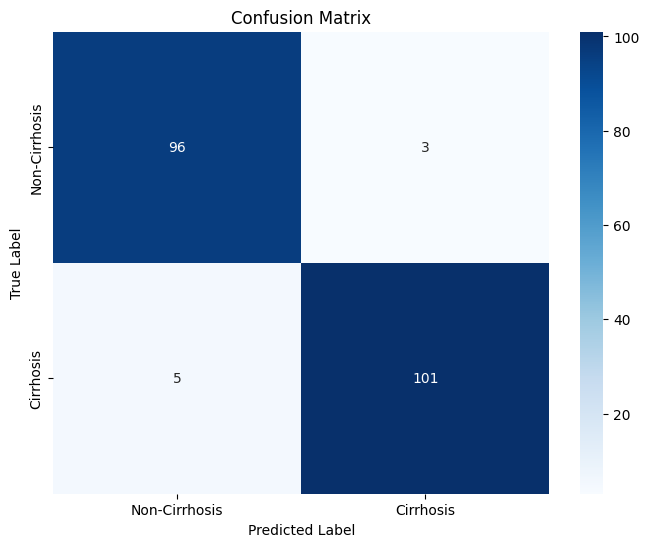

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Visualize confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Cirrhosis', 'Cirrhosis'],
            yticklabels=['Non-Cirrhosis', 'Cirrhosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()